## MOSAiC track LWP extraction from Climate-DT story-nudging

This notebook reads an hourly ship track (time, latitude, longitude), requests total column liquid water (LWP, `tclw`) from the Climate-DT story-nudging experiment via Polytope/Earthkit, and writes the merged results to CSV.

The extraction is done day-by-day so each ship position on a given day is sampled from that day's model field.

### Authentication
Run the authentication helper from the repository root if needed.

In [ ]:
# %%capture cap
# %run ./desp-authentication.py

In [ ]:
# output_1 = cap.stdout.split('}\n') 
# access_token = output_1[-1][0:-1]
# print('Authentication token captured.')

Authentication token captured.


In [ ]:
# Run the authentication script — you will be prompted for your DESP username and password
%run ./../desp-authentication.py

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import earthkit.data
import matplotlib.pyplot as plt
from polytope_zarr import PolytopeZarrStore

### Settings

In [23]:
TRACK_FILE = Path('MOSAiC_track_1h.txt')

### Read and prepare ship track

In [24]:
track = pd.read_csv(TRACK_FILE, sep=r'\s+')
track = track.rename(columns={'Datetime': 'time_raw', 'Latitude': 'lat', 'Longitude': 'lon'})
track['time'] = pd.to_datetime(track['time_raw'].astype(str), format='%Y%m%d%H', utc=True).dt.tz_convert(None)
track = track[['time', 'lat', 'lon']].copy()

# Normalize longitude to [-180, 180] for consistency in output.
track['lon'] = ((track['lon'] + 180.0) % 360.0) - 180.0
track['date_str'] = track['time'].dt.strftime('%Y%m%d')
track['time_str'] = track['time'].dt.strftime('%H%M')
track


,time,lat,lon,date_str,time_str
0,2019-09-20 17:00:00,69.67955,18.99664,20190920,1700
1,2019-09-20 18:00:00,69.67955,18.99665,20190920,1800
2,2019-09-20 19:00:00,69.68378,19.02527,20190920,1900
3,2019-09-20 20:00:00,69.80262,19.41134,20190920,2000
4,2019-09-20 21:00:00,69.91434,19.89519,20190920,2100
...,...,...,...,...,...
9296,2020-10-12 01:00:00,54.15229,7.45162,20201012,0100
9297,2020-10-12 02:00:00,54.03084,7.56408,20201012,0200
9298,2020-10-12 03:00:00,53.90926,7.68643,20201012,0300
9299,2020-10-12 04:00:00,53.83636,8.06298,20201012,0400


In [ ]:
# Split off the part of the drift that ScenarioMIP can serve (SSP3-7.0 starts
# 2020-01-01): track_2020 holds only dates from 2020 onwards. track keeps the
# full drift for story-nudging; uncomment the last line to trim it to 2019 only.
track_2020 = track[track['time'] >= '2020-01-01'].reset_index(drop=True)
# track = track[track['time'] < '2020-01-01'].reset_index(drop=True)

print(f'track:      {len(track):,} rows, {track.time.min()} to {track.time.max()}')
print(f'track_2020: {len(track_2020):,} rows, {track_2020.time.min()} to {track_2020.time.max()}')

### Trajectory feature request from the ship track

Alternative to the zarr-store nearest-neighbour sampling below: ask Polytope directly for values *along the track* with a `trajectory` feature request (server-side feature extraction, so only the track points are transferred — no full fields).

One request per track day: the day's hourly positions go into `feature.points` and the matching hours into `time`. Note that Polytope evaluates **every point at every requested time**, so the along-track series is the diagonal of the result (point *i* at hour *i*). `inflation` is the radius (in degrees) around each point within which grid cells are collected.

(polytope-mars also supports a per-point `datetime` axis for climate datasets — `"axes": ["latitude", "longitude", "datetime"]` with points `[lat, lon, datetime]` — which would allow the whole track in a single request.)

In [ ]:
# Build a Polytope trajectory feature request from a ship track, one day at a time.
# Valid Climate-DT combinations (generation 2):
#   story-nudging: model ifs-fesom, experiments "cont"/"hist"/"Tplus2.0K",
#                  2017-2024 -> full drift (df=track), MN5 bridge
#   scenariomip:   model ifs-nemo, experiment "ssp3-7.0", from 2020-01-01
#                  -> 2020 part only (df=track_2020), LUMI bridge
def track_trajectory_request(date_str, df=None, param="2t",
                             activity="story-nudging", experiment="hist",
                             model="ifs-fesom", inflation=0.5):
    if df is None:
        df = track

    day = df[df.date_str == date_str]
    if day.empty:
        raise ValueError(
            f"No track points on {date_str}: this track covers "
            f"{df.date_str.iloc[0]} to {df.date_str.iloc[-1]}"
            )

    # At 85-88N the HEALPix cells sit several degrees of longitude apart, so a
    # fixed round inflation often contains no cell centre and Polytope answers
    # "No data". Use a box widened in longitude by 1/cos(lat) instead, so the
    # search area keeps a constant physical size along the whole drift.
    lon_inflation = float(inflation / np.cos(np.deg2rad(day.lat.abs().max())))
    return {
        "class": "d1",                        ## DestinE
        "dataset": "climate-dt",
        "activity": activity,
        "experiment": experiment,
        "generation": "2",
        "realization": "1",
        "model": model,
        "resolution": "standard",
        "expver": "0001",
        "stream": "clte",
        "type": "fc",
        "levtype": "sfc",
        "param": param,                        ## "tclw" = LWP (paramId 78)
        "date": date_str,
        "time": "/".join(day.time_str),
        "feature": {
            "type": "trajectory",
            "points": day[["lat", "lon"]].values.tolist(),
            "inflation": [inflation, round(lon_inflation, 3)],  ## [lat, lon] degrees
            "inflate": "box",
            "axes": ["latitude", "longitude"],
        },
    }

# traj_request = track_trajectory_request(track.date_str.iloc[0])
traj_request = track_trajectory_request(track.date_str.iloc[0])

# ScenarioMIP variant for the 2020 part of the drift (fetch from the LUMI address):
# traj_request = track_trajectory_request(track_2020.date_str.iloc[0], df=track_2020,
#                                         activity="scenariomip", experiment="ssp3-7.0",
#                                         model="ifs-nemo")

# print(f"{len(traj_request['feature']['points'])} track points on {traj_request['date']}, "
#       f"times {traj_request['time']}")
traj_request

In [ ]:
import gc
from pathlib import Path

out_dir = Path("traj_daily")
out_dir.mkdir(exist_ok=True, parents=True)

# [15:16] -> just the 16th track day; use [:] (or drop the slice) for all days
for date_str in track["date_str"].unique()[15:16]:

    date_fmt = date_str.replace("-", "")  # yyyymmdd, adjust if date_str format differs
    out_path = out_dir / f"traj_{date_fmt}.nc"

    if out_path.exists():
        print(f"skip {out_path}, already done")
        continue

    traj_request = track_trajectory_request(date_str)  # unchanged function

    data = earthkit.data.from_source(
        "polytope", "destination-earth", traj_request,
        address="polytope.mn5.apps.dte.destination-earth.eu", stream=False,
    )
    ds_day = data.to_xarray()

    ds_day.to_netcdf(out_path)
    print(f"saved {out_path}")

    ds_day.close()
    del ds_day
    gc.collect()

In [ ]:
# Fetch one day along the track and decode the CoverageJSON result.
# The result holds every track point at every requested hour; the along-track
# series is the diagonal (point i at hour i).
# NOTE: story-nudging lives on the MN5 bridge; the lumi endpoint serves other
# Climate-DT datasets and returns "No data" for this request.
data = earthkit.data.from_source(
    "polytope", "destination-earth", traj_request,
    address="polytope.mn5.apps.dte.destination-earth.eu", stream=False,
)
ds_traj = data.to_xarray()
ds_traj

### Carmen: I use below code to generate daily csv files

In [ ]:
track = pd.read_csv('./MOSAiC_track_1h.txt', sep=r'\s+')
track = track.rename(columns={'Datetime':'time_raw','Latitude':'lat','Longitude':'lon'})
track['time'] = pd.to_datetime(track['time_raw'].astype(str), format='%Y%m%d%H')
track['lon'] = ((track['lon']+180.0)%360.0)-180.0
track['date_str'] = track['time'].dt.strftime('%Y%m%d')
track['time_str'] = track['time'].dt.strftime('%H%M')

def track_trajectory_request(date_str, df=track, param="10si", activity="story-nudging",
                            experiment="cont", model="ifs-fesom", inflation=2):             #inflation change accordingly for the ship track
   day = df[df.date_str==date_str]
   # box inflation widened in longitude by 1/cos(lat): at 85-88N the HEALPix
   # cells sit degrees of longitude apart, a round 0.5 deg circle often holds
   # no cell centre and Polytope answers "No data" (HTTP 400) on those days
   lon_inflation = float(inflation/np.cos(np.deg2rad(day.lat.abs().max())))
   return {"class":"d1","dataset":"climate-dt","activity":activity,"experiment":experiment,
           "generation":"2","realization":"1","model":model,"resolution":"standard",
           "expver":"0001","stream":"clte","type":"fc","levtype":"sfc","param":param,
           "date":date_str,"time":"/".join(day.time_str),
           "feature":{"type":"trajectory","points":day[["lat","lon"]].astype(float).values.tolist(),
                      "inflation":[inflation, round(lon_inflation,3)],"inflate":"box","axes":["latitude","longitude"]}}

def fetch_day_along_track(date_str, df=track, **kw):
   day = df[df.date_str==date_str]
   req = track_trajectory_request(date_str, df=df, **kw)
   data = earthkit.data.from_source("polytope","destination-earth",req,
       address="polytope.mn5.apps.dte.destination-earth.eu",stream=False)
   ds = data.to_xarray()
   var = req["param"]
   lats = ds.latitude.values
   lons = ((ds.longitude.values+180.0)%360.0)-180.0
   ds_times = pd.to_datetime(ds.datetimes.values, utc=True).tz_convert(None)
   print("ds datetimes order:", list(ds.datetimes.values)[:3], "...")
   out = day[["time","lat","lon"]].copy(); vals=[]
   for _, row in day.iterrows():
       i = int(np.where(ds_times==row.time)[0][0])
       dlon = np.abs(lons-row.lon); dlon = np.minimum(dlon, 360.0-dlon)
       d2 = (lats-row.lat)**2 + (np.cos(np.deg2rad(row.lat))*dlon)**2
       vals.append(float(ds[var].isel(datetimes=i, points=int(np.argmin(d2))).squeeze()))
   out[var]=vals
   return out

In [ ]:
import gc
import pandas as pd
from pathlib import Path

base_dir = ('~/Git/PISCO_notebooks/Data')
#out_dir = Path('/proj/naiss2024-22-523/Polar_hackathon/Data/IFS/daily')
out_dir = Path(f"{base_dir}/IFS-daily")
out_dir.mkdir(exist_ok=True, parents=True)

for d in track.date_str.unique():

    out_path = out_dir / f"2t_ctrl_{d}.csv"

    if out_path.exists():
        print(f"skip {out_path}, already done")
        continue

    try:
        result = fetch_day_along_track(d)
    except Exception as e:
        print(f"{d} failed: {e}")
        continue

    result.to_csv(out_path, sep=',')
    print(f"saved {out_path}")

    del result
    gc.collect()

### IFS-FESOM Data plot

In [27]:
base_dir = ('~/Git/PISCO_notebooks/Data')

ds_mosaic_full = xr.open_dataset(f"{base_dir}/MOSAiC_obs_combined_1h_v2.nc")
ds_mosaic_full
# obs_time = pd.to_datetime(ds_mosaic_full.time.values,format='%Y%m%d')

<xarray.Dataset> Size: 70MB
Dimensions:                    (time: 9318, height: 596)
Coordinates:
  * time                       (time) datetime64[ns] 75kB 2019-09-20 ... 2020...
  * height                     (height) float32 2kB 160.0 190.0 ... 1.801e+04
Data variables: (12/54)
    lat                        (time) float64 75kB ...
    lon                        (time) float64 75kB ...
    temp_2m                    (time) float64 75kB ...
    temp_6m                    (time) float64 75kB ...
    temp_10m                   (time) float64 75kB ...
    skin_temp_surface          (time) float64 75kB ...
    ...                         ...
    up_long_hemisp_mean        (time) float64 75kB ...
    down_short_hemisp_mean     (time) float64 75kB ...
    up_short_hemisp_mean       (time) float64 75kB ...
    lwc                        (time, height) float32 22MB ...
    iwc                        (time, height) float32 22MB ...
    temperature                (time, height) float32 22MB ...

In [37]:
df_mosaic = pd.DataFrame({
    "time": pd.to_datetime(ds_mosaic_full.time.to_series()),
    "lat": ds_mosaic_full.lat.to_series(),
    "lon": ds_mosaic_full.lon.to_series(),
    "obs_t2m": ds_mosaic_full.temp_2m.to_series(),
    "obs_10si": ds_mosaic_full.wspd_vec_mean_10m.to_series()
})

df_mosaic = df_mosaic.reset_index(drop=True)
 
# 2m air temperature csv read
df_2t_ctrl = pd.read_csv(f"{base_dir}/IFS-FESOM/2t_ctrl.csv", sep=',', index_col=0)
df_2t_hist = pd.read_csv(f"{base_dir}/IFS-FESOM/2t_hist.csv", sep=',', index_col=0)
 
df_2t_ctrl= df_2t_ctrl.rename(columns={df_2t_ctrl.columns[0]: 'time'})
df_2t_ctrl['time'] = pd.to_datetime(df_2t_ctrl['time'])

df_2t_hist = df_2t_hist.rename(columns={df_2t_hist.columns[0]: 'time'})
df_2t_hist['time'] = pd.to_datetime(df_2t_hist['time'])
 
df_merge = pd.merge(df_mosaic, df_2t_ctrl, on='time', how='left')
df_merge = df_merge.sort_values('time').reset_index(drop=True)
df_merge = df_merge.drop(["lat_y","lon_y"],axis=1)
df_merge = df_merge.rename(columns={"2t": "IFS_2t_ctrl"})

df_merge = pd.merge(df_merge, df_2t_hist, on='time', how='left')
df_merge = df_merge.sort_values('time').reset_index(drop=True)
df_merge = df_merge.drop(["lat","lon"],axis=1)
df_merge = df_merge.rename(columns={"2t": "IFS_2t_hist"})
display(df_merge)
 

,time,lat_x,lon_x,obs_t2m,obs_10si,IFS_2t_ctrl,IFS_2t_hist
0,2019-09-20 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-09-20 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-09-20 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-09-20 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN
4,2019-09-20 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
9313,2020-10-12 01:00:00,54.15229,7.45162,NaN,NaN,284.502457,284.743568
9314,2020-10-12 02:00:00,54.03084,7.56408,NaN,NaN,284.561462,284.588158
9315,2020-10-12 03:00:00,53.90926,7.68643,NaN,NaN,284.529663,284.760193
9316,2020-10-12 04:00:00,53.83636,8.06298,NaN,NaN,284.462791,284.678192


In [38]:
df_merge2 = df_merge.copy()

# 10m wind speed csv read
df_10si_ctrl = pd.read_csv(f"{base_dir}/IFS-FESOM/10si_ctrl.csv", sep=',', index_col=0)
df_10si_hist = pd.read_csv(f"{base_dir}/IFS-FESOM/10si_hist.csv", sep=',', index_col=0)

df_10si_ctrl = df_10si_ctrl.rename(columns={df_10si_ctrl.columns[0]: 'time'})
df_10si_ctrl['time'] = pd.to_datetime(df_10si_ctrl['time'])

df_10si_hist = df_10si_hist.rename(columns={df_10si_hist.columns[0]: 'time'})
df_10si_hist['time'] = pd.to_datetime(df_10si_hist['time'])

df_merge2 = pd.merge(df_merge2, df_10si_hist, on='time', how='left')
df_merge2 = df_merge2.sort_values('time').reset_index(drop=True)
df_merge2 = df_merge2.drop(["lat","lon"],axis=1)
df_merge2 = df_merge2.rename(columns={"10si": "IFS_10si_hist"})

df_merge2 = pd.merge(df_merge2, df_10si_ctrl, on='time', how='left')
df_merge2 = df_merge2.sort_values('time').reset_index(drop=True)
df_merge2 = df_merge2.drop(["lat","lon"],axis=1)
df_merge2 = df_merge2.rename(columns={"10si": "IFS_10si_ctrl"})

display(df_merge2)

,time,lat_x,lon_x,obs_t2m,obs_10si,IFS_2t_ctrl,IFS_2t_hist,IFS_10si_hist,IFS_10si_ctrl
0,2019-09-20 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-09-20 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-09-20 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-09-20 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019-09-20 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
9313,2020-10-12 01:00:00,54.15229,7.45162,NaN,NaN,284.502457,284.743568,4.455077,3.613343
9314,2020-10-12 02:00:00,54.03084,7.56408,NaN,NaN,284.561462,284.588158,4.377552,3.638189
9315,2020-10-12 03:00:00,53.90926,7.68643,NaN,NaN,284.529663,284.760193,3.656043,3.398463
9316,2020-10-12 04:00:00,53.83636,8.06298,NaN,NaN,284.462791,284.678192,3.530072,3.291712


<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1589886/1630939032.py:16: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_title('10m wind speed [$\mathrm{ms}^{-1}$]')


Text(0.5, 1.0, '10m wind speed [$\\mathrm{ms}^{-1}$]')

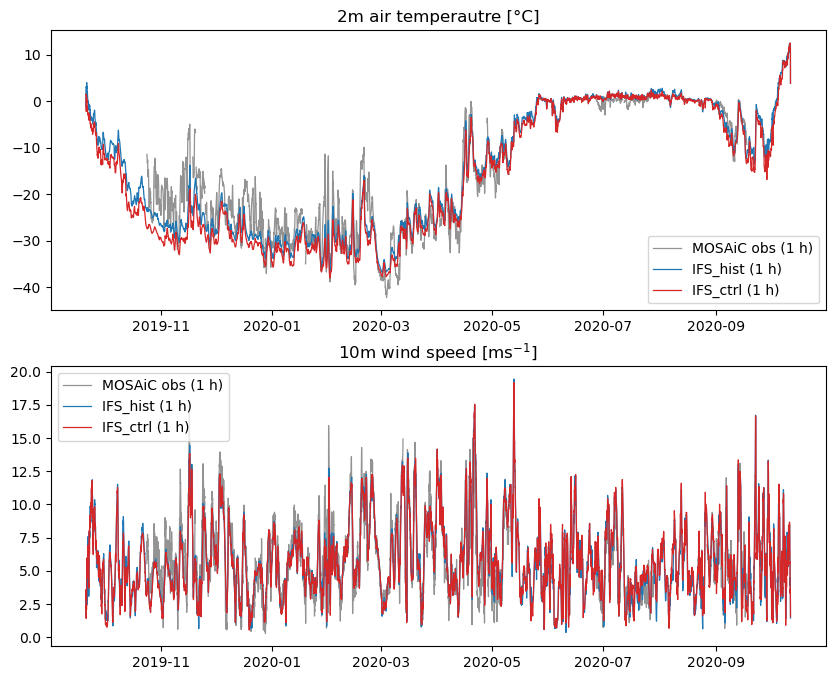

In [43]:
colors = {"MOSAiC obs": "grey", "IFS_ctrl": "tab:red", "IFS_hist": "tab:blue"}
fig, axes = plt.subplots(2,1,figsize=(10, 8))

ax1 = axes[0]
ax1.plot(df_merge2['time'], df_merge2['obs_t2m'], color=colors["MOSAiC obs"], lw=0.9, alpha=0.85, label="MOSAiC obs (1 h)")
ax1.plot(df_merge2['time'], df_merge2['IFS_2t_hist']-273.15, color=colors["IFS_hist"], lw=0.9, label="IFS_hist (1 h)")
ax1.plot(df_merge2['time'], df_merge2['IFS_2t_ctrl']-273.15, color=colors["IFS_ctrl"], lw=0.9, label="IFS_ctrl (1 h)")
ax1.legend()
ax1.set_title('2m air temperautre [°C]')

ax2 = axes[1]
ax2.plot(df_merge2['time'], df_merge2['obs_10si'], color=colors["MOSAiC obs"], lw=0.9, alpha=0.85, label="MOSAiC obs (1 h)")
ax2.plot(df_merge2['time'], df_merge2['IFS_10si_hist'], color=colors["IFS_hist"], lw=0.9, label="IFS_hist (1 h)")
ax2.plot(df_merge2['time'], df_merge2['IFS_10si_ctrl'], color=colors["IFS_ctrl"], lw=0.9, label="IFS_ctrl (1 h)")
ax2.legend()
ax2.set_title('10m wind speed [$\mathrm{ms}^{-1}$]')